# Deep Convolutional GAN (DCGAN)

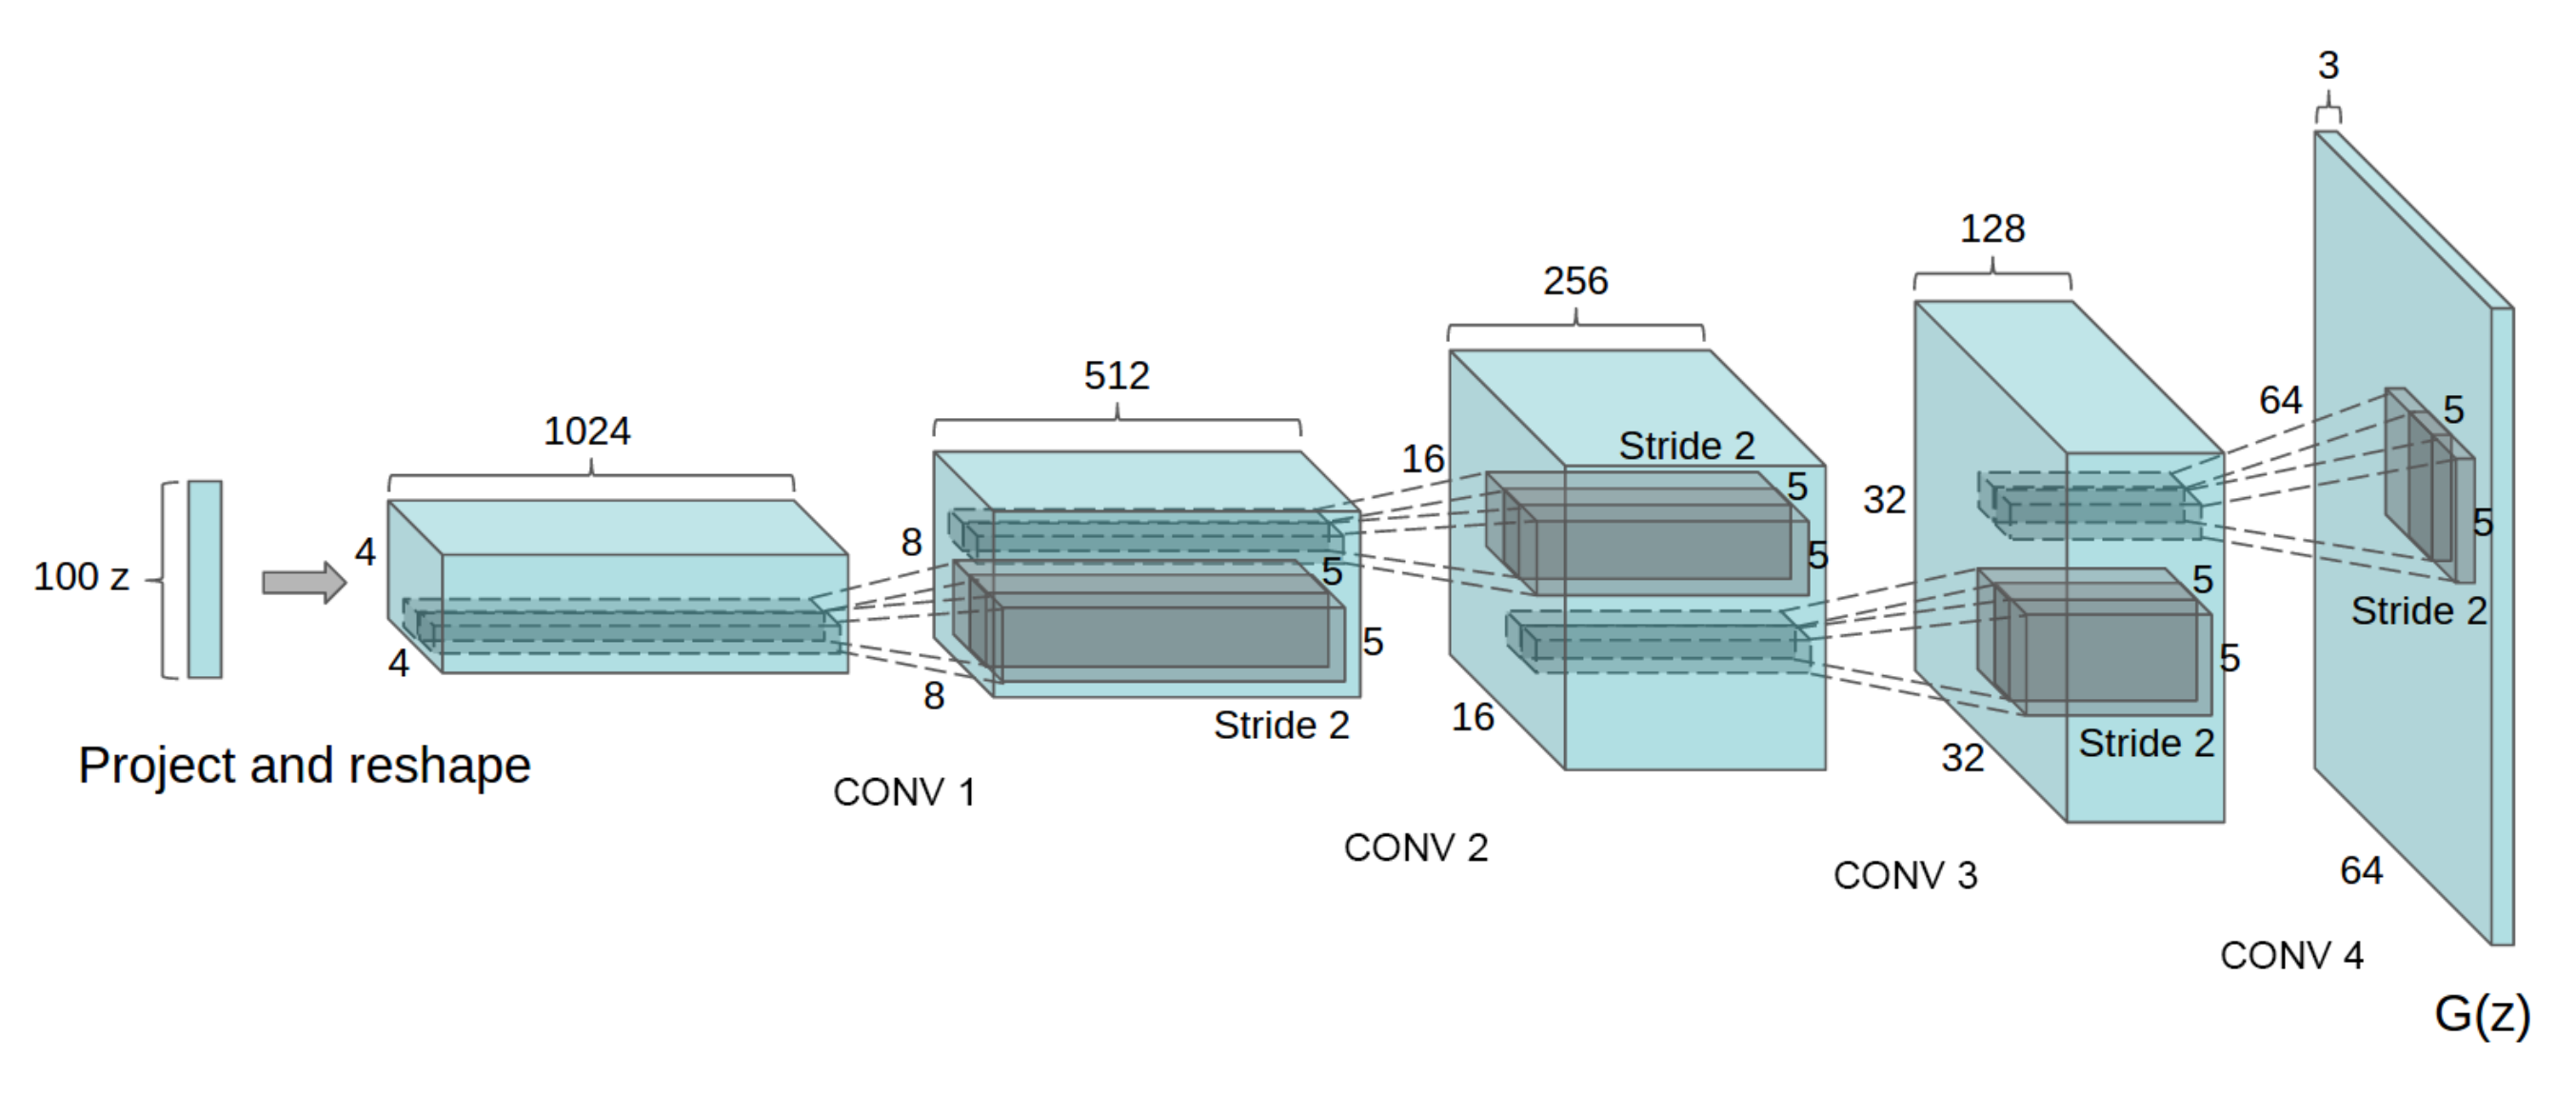

In [2]:
from IPython.display import Image, display
display(Image(filename='/kaggle/input/dcgan1/dcgan-gen.png'))

Points

- Use convolutions without any pooling layers
- Use batchnorm in both the generator and the discriminator
Don't use fully connected hidden layers
- Use ReLU activation in the generator for all layers except for the output, which uses a Tanh activation.
- Use LeakyReLU activation in the discriminator for all layers except for the output, which does not use an activation

In [2]:
import torch
from torch import nn
from tqdm.auto import tqdm
from torchvision import transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torchvision.utils as vutils

In [3]:
pip install torchinfo

Note: you may need to restart the kernel to use updated packages.


In [4]:
import torchinfo

### Generator

In [5]:
class Generator(nn.Module):
  def __init__(self,z_dim=10,im_chan=1,hidden_dim=64):
    super().__init__()
    self.gen = nn.Sequential(
        self.make_gen_block(z_dim, hidden_dim * 4),
        self.make_gen_block(hidden_dim * 4, hidden_dim * 2, kernel_size=4, stride=1),
        self.make_gen_block(hidden_dim * 2, hidden_dim),
        self.make_gen_block(hidden_dim, im_chan, kernel_size=4, final_layer=True),
    )

  def make_gen_block(self,input_channels,output_channels,kernel_size=3,stride=2,final_layer=False):
    if not final_layer:
      return nn.Sequential(
          nn.ConvTranspose2d(input_channels,output_channels,kernel_size=kernel_size,stride=stride),
          nn.BatchNorm2d(output_channels),
          nn.ReLU(inplace=True)
      )
    else:
      return nn.Sequential(
          nn.ConvTranspose2d(input_channels,output_channels,kernel_size=kernel_size,stride=stride),
          nn.Tanh()
      )

  def forward(self, noise):
    x = noise.view(len(noise), 64, 1, 1)
    return self.gen(x)

  def get_noise(n_samples,z_dim,device='cpu'):
    return torch.randn(n_samples,z_dim,device=device)





### Discriminator

In [6]:
class Discriminator(nn.Module):
  def __init__(self,im_chan=1,hidden_dim=16):
    super().__init__()

    self.disc= nn.Sequential(
        self.make_disc_block(im_chan,hidden_dim),
        self.make_disc_block(hidden_dim,hidden_dim*2),
        self.make_disc_block(hidden_dim*2,1,final_layer=True)
    )

  def make_disc_block(self,input_channels,output_channels,kernel_size=4,stride=2,final_layer=False):
    if not final_layer:
      return nn.Sequential(
          nn.Conv2d(input_channels,output_channels,kernel_size=kernel_size,stride=stride),
          nn.BatchNorm2d(output_channels),
          nn.LeakyReLU(0.2,inplace=True)
      )
    else:
      return nn.Sequential(
          nn.Conv2d(input_channels, output_channels, kernel_size, stride)
      )

  def forward(self,image):
    disc_pred=self.disc(image)
    return disc_pred.view(len(disc_pred),-1)


### loss optimizer

In [7]:
criterion = nn.BCEWithLogitsLoss()

In [13]:
z_dim = 64
lr = 0.0002

beta_1 = 0.5
beta_2 = 0.999
device = 'cuda'

In [14]:
gen = Generator(z_dim).to(device)
gen_opt = torch.optim.Adam(gen.parameters(), lr=lr, betas=(beta_1, beta_2))
disc = Discriminator().to(device)
disc_opt = torch.optim.Adam(disc.parameters(), lr=lr, betas=(beta_1, beta_2))

### weights

In [15]:
def weights_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
    if isinstance(m, nn.BatchNorm2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
        torch.nn.init.constant_(m.bias, 0)
gen = gen.apply(weights_init)
disc = disc.apply(weights_init)

### Dataset

In [11]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

dataloader = DataLoader(
    MNIST('.', download=True, transform=transform),
    batch_size=128,
    shuffle=True)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 57.0MB/s]


Extracting ./MNIST/raw/train-images-idx3-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 1.74MB/s]


Extracting ./MNIST/raw/train-labels-idx1-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 14.7MB/s]


Extracting ./MNIST/raw/t10k-images-idx3-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 6.03MB/s]

Extracting ./MNIST/raw/t10k-labels-idx1-ubyte.gz to ./MNIST/raw



### Train

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 9 Loss D: 0.3425 | Loss G: 1.5992


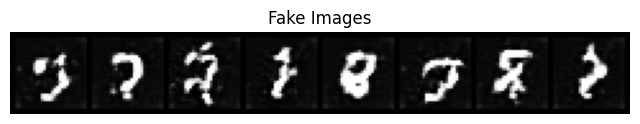

Epoch 19 Loss D: 0.4724 | Loss G: 1.2232


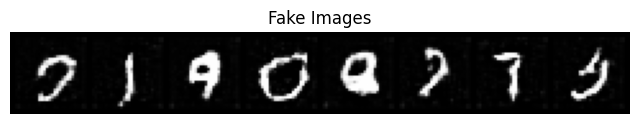

Epoch 29 Loss D: 0.5360 | Loss G: 1.0863


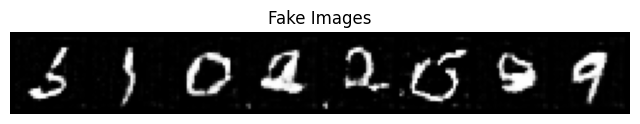

Epoch 39 Loss D: 0.5836 | Loss G: 1.0204


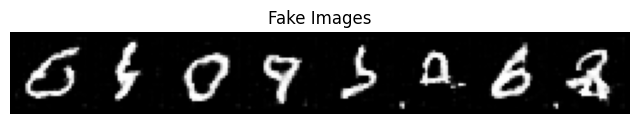

Epoch 49 Loss D: 0.6084 | Loss G: 0.9462


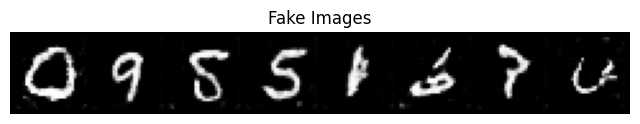

Epoch 59 Loss D: 0.6314 | Loss G: 0.8907


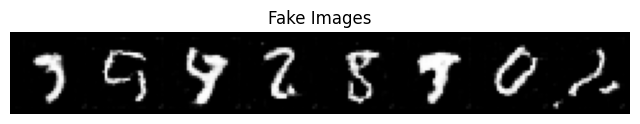

Epoch 69 Loss D: 0.6448 | Loss G: 0.8412


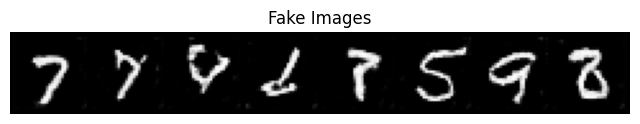

Epoch 79 Loss D: 0.6537 | Loss G: 0.8174


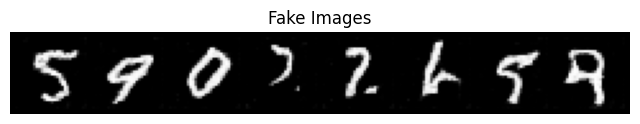

Epoch 89 Loss D: 0.6633 | Loss G: 0.7910


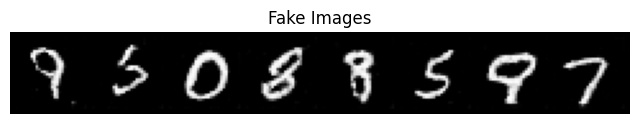

Epoch 99 Loss D: 0.6716 | Loss G: 0.7669


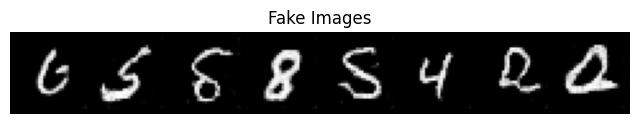

In [16]:
n_epochs = 100

gen = gen.to(device)
disc = disc.to(device)
gen.train()
disc.train()

for epoch in tqdm(range(n_epochs)):
    discriminator_loss = 0
    generator_loss = 0
    for real, _ in dataloader:
        cur_batch_size = len(real)
        real = real.to(device)

        # Train Discriminator
        for i in range(3):
          disc_opt.zero_grad()
          fake_noise = Generator.get_noise(cur_batch_size, z_dim, device=device)
          fake = gen(fake_noise)
          disc_fake_pred = disc(fake.detach())
          disc_fake_loss = criterion(disc_fake_pred, torch.zeros_like(disc_fake_pred))

          disc_real_pred = disc(real)
          disc_real_loss = criterion(disc_real_pred, torch.ones_like(disc_real_pred))

          disc_loss = (disc_fake_loss + disc_real_loss) / 2
          disc_loss.backward()
          disc_opt.step()


        # Train Generator
        gen_opt.zero_grad()
        fake_noise = Generator.get_noise(cur_batch_size, z_dim, device=device)
        fake = gen(fake_noise)
        disc_fake_pred = disc(fake)
        gen_loss = criterion(disc_fake_pred, torch.ones_like(disc_fake_pred))
        gen_loss.backward()
        gen_opt.step()

        discriminator_loss += disc_loss.item()
        generator_loss += gen_loss.item()

    discriminator_loss /= len(dataloader)
    generator_loss /= len(dataloader)

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch} Loss D: {discriminator_loss:.4f} | Loss G: {generator_loss:.4f}")

        fake_noise = Generator.get_noise(8, z_dim, device=device)
        fake = gen(fake_noise)
        grid = vutils.make_grid(fake.detach().cpu(), padding=2, normalize=True)

        plt.figure(figsize=(8, 8))
        plt.axis("off")
        plt.title("Fake Images")
        plt.imshow(np.transpose(grid, (1, 2, 0)))
        plt.show()
